In [1]:
import sys

sys.path.append("../")
from visualisation import *

In [14]:
df = pd.read_csv("/mnt/d/bom_nci/2023/NCI_processed_Adelaide_grouped.csv")
# df = df.query(f"postcode == 5007")

df["time"] = pd.to_datetime(df["time"])
df["time"] = df["time"].dt.tz_localize("utc")
df["time"] = df["time"].dt.tz_convert(pytz.FixedOffset(10 * 60))
# df.set_index('time', inplace=True)
# min_time = df.index.min()
# max_time = df.index.max()
# full_time_range = pd.date_range(start=min_time,
#                                 end=max_time,
#                                 freq='10min')

# # Reindex and fill missing entries with zero
# df = df.reindex(full_time_range, fill_value=None).reset_index()
# df = df.interpolate(method='linear',  limit=1, limit_direction='both')
# df = df.fillna(0)
# df['time'] = df.pop('index')
df = df.sort_values("time")
df["groupid"] = ""
df["time"].min(), df["time"].max()

(Timestamp('2023-01-01 05:30:00+1000', tz='pytz.FixedOffset(600)'),
 Timestamp('2023-12-31 19:50:00+1000', tz='pytz.FixedOffset(600)'))

In [3]:
df["time"].diff().unique()

<TimedeltaArray>
[NaT, '0 days 00:10:00']
Length: 2, dtype: timedelta64[ns]

In [7]:
df["quality_mask"].unique()

array([ 1., nan])

saved as:  /home/hossein/CICCADA/tests/Figures/GHI_Adelaide_January_2023.jpeg


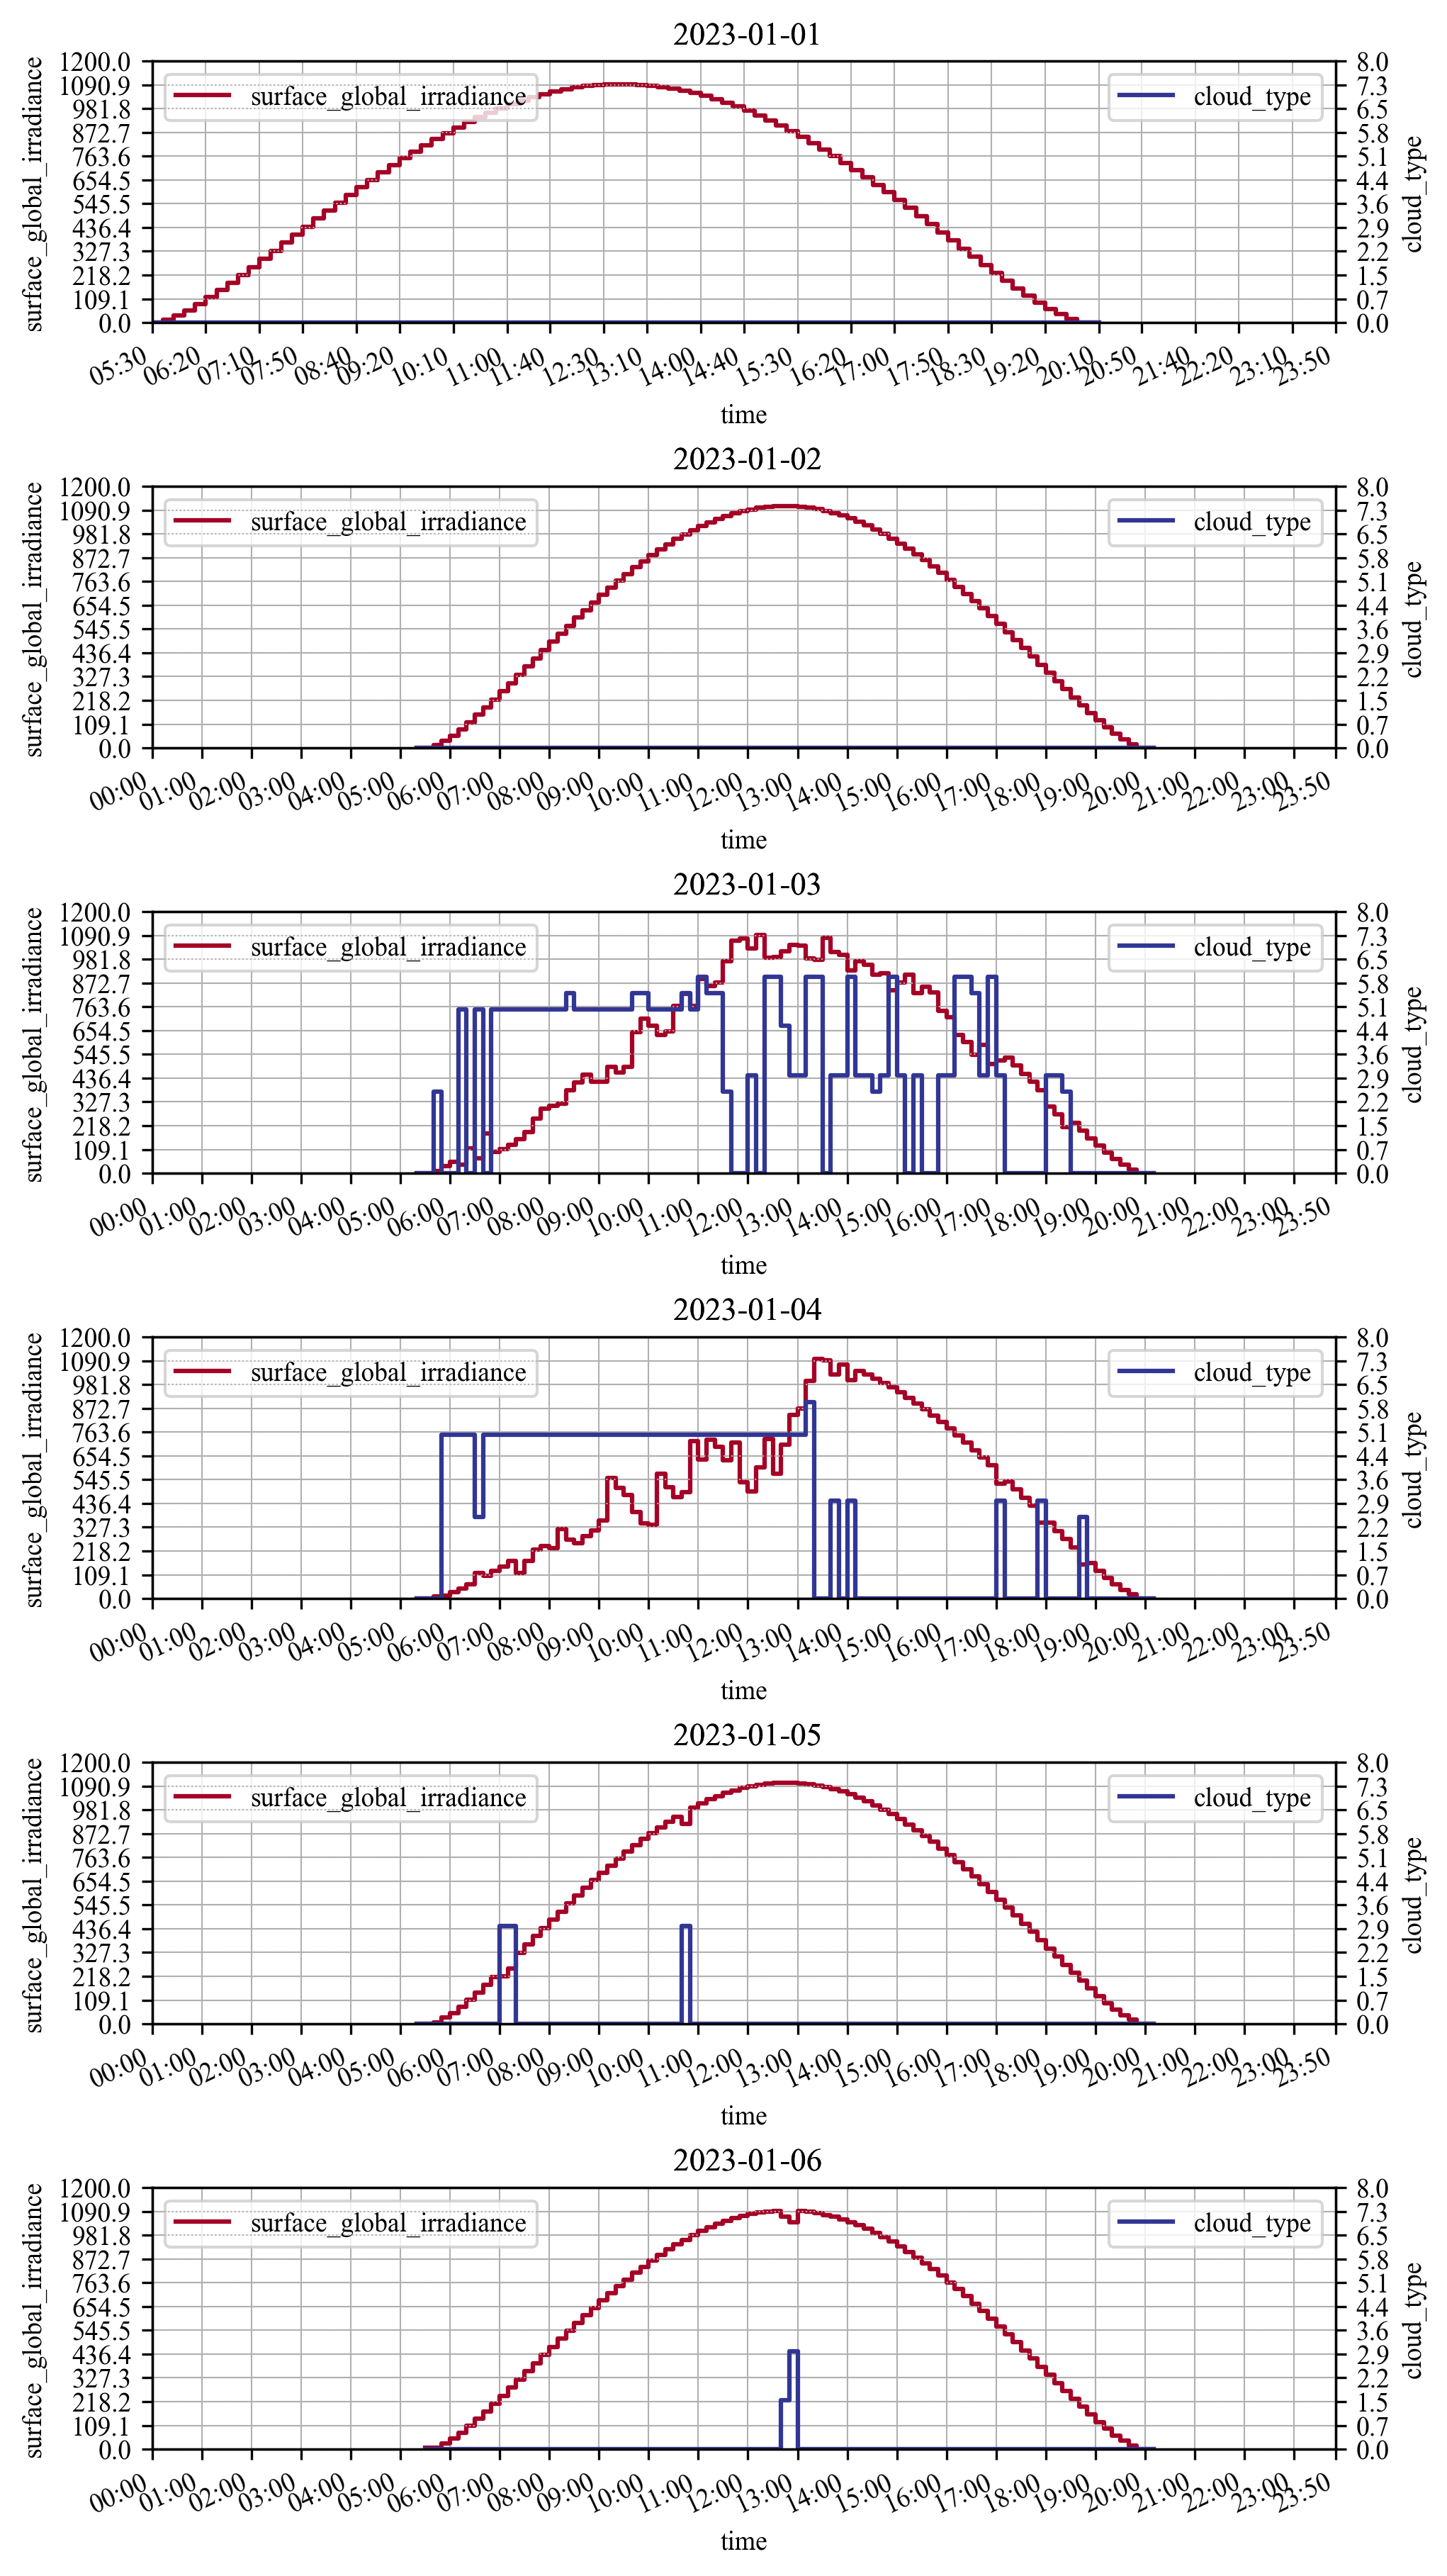

In [4]:
start_time = "2023-01-01 00:00:00+10:00"  # In sydney local time
end_time = "2023-01-07 00:00:00+10:00"  # In sydney local time

num_ticks = 25
save_as = "Figures/GHI_Adelaide_January_2023.jpeg"
x_label = "time"
y_labels = ["surface_global_irradiance", "cloud_type"]
plt_config = {
    "surface_global_irradiance": [0, 0, "-", 0, 1200],
    "cloud_type": [0, 1, "-", -0, 8],
}
special_legend = []
color_nights = False
kW2MW_attr = []
ax_digit = "1.1f"
a = my_plot4(
    start_time,
    end_time,
    df,
    plt_config=plt_config,
    ax_digit=ax_digit,
    group_attr="groupid",
    time_attr="time",
    color_nights=color_nights,
    cmap="RdYlBu",
    figsize=[17 / 2.54, 2.0],
    same_scale=False,
    fontsize=9,
    fontname="Times New Roman",
    plot_total=False,
    plot_total_func=["sum", [lambda x: max(x), "max"]],
    E2P_attr=None,
    num_ticks=num_ticks,
    num_yticks=12,
    dpi=300,
    special_legend=special_legend,
    x_format="%H:%M",
    MW=False,
    legend_loc=["upper left", "upper right"],
    x_label=x_label,
    y_labels=y_labels,
    kW2MW_attr=kW2MW_attr,
    plot_period=np.timedelta64(1, "D"),
    save_as=save_as,
    rotation=25,
    step=True,
    gridwidth=[0.5, 0.5],
    legend_join="",
    title="",
    legend_i=0,
    title_i=0,
    only1title=0,
)
a.do()

In [ ]:
# df['day'] = df['time'].dt.date

In [16]:
df_cloud_type = (
    df.groupby(["time", "postcode"]).agg({"cloud_type": "sum"}).reset_index()
)
df_cloud_type = (
    df_cloud_type.groupby("postcode")
    .agg({"cloud_type": lambda x: x[x == 0].count()})
    .reset_index()
)
df_cloud_type = df_cloud_type.sort_values("cloud_type", ascending=False)
df_cloud_type.columns = ["postcode", "num_clear_days"]

In [22]:
9457 / 6 / 8

197.02083333333334

In [17]:
df_cloud_type

,postcode,num_clear_days
11,5016.0,15815
12,5017.0,14924
27,5044.0,14862
15,5022.0,14783
14,5021.0,14764
...,...,...
82,5134.0,10803
69,5114.0,10776
76,5125.0,10305
93,5152.0,9946
